# Multi-scenario portfolio stress comparison

Canonical hazard rows already carry `pathway` and `horizon`. Pack several
sensitivity cases into one Parquet file and the same
`HazardDataset.for_assets(...).return_periods(...).write_parquet(...)` call emits
one row per asset × scenario — no separate evaluation code path.

This offline notebook derives two transparent tail stresses from the checked-in
historical WRI fixture:

- **historical / 1980** — fitted baseline
- **tail_stress_10pct / 2050** — fitted tail scale × 1.10
- **tail_stress_20pct / 2050** — fitted tail scale × 1.20

These are sensitivity cases for demonstrating scenario mechanics, not calibrated
climate-model projections.


**Workflow:** [AI skill](../.agents/skills/crc-assess-asset-portfolio-risk/SKILL.md) · [Python pipeline](../pipelines/multi_scenario_pipeline.py) · [Setup and tested versions](../ai-playbooks/docs/setup.md) · [All problems](../README.md#choose-a-problem)

### Viewing this notebook

**GitHub:** saved tables and PNG figures below show the completed run; no execution
is needed. **JupyterLab / compatible editors:** run all cells for interactive
Plotly charts with hover, zoom and pan. Each figure also includes a static PNG
fallback. Maps need internet access for basemap tiles; PMTiles downloads, where
provided, open separately in a compatible viewer.


In [1]:
from hashlib import sha256
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pyarrow as pa
import pyarrow.parquet as pq

from crc_sdk.connectors import (
    read_hazard_dataset,
    read_hazard_metadata,
    write_hazard_dataset,
)
from crc_sdk.workflows import ExecutionOptions, HazardDataset, return_period_value_columns

# One MIME bundle: interactive Plotly where supported, PNG for GitHub.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 1100
pio.renderers["png"].height = 550
pio.renderers["png"].scale = 1

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
FIXTURE_DIR = Path("../fixtures/os_climate")

HAZARD_NAME = "RiverineInundation"
RETURN_PERIODS = [100, 500, 1000]
SCENARIOS = [
    ("historical", 1980, 1.0),
    ("tail_stress_10pct", 2050, 1.1),
    ("tail_stress_20pct", 2050, 1.2),
]

BASELINE_PATH = FIXTURE_DIR / "hazard.parquet"
ASSETS_PATH = FIXTURE_DIR / "assets.parquet"
HAZARD_PATH = DATA_DIR / "wri_riverine_stress_scenarios_cologne.parquet"
EVAL_PATH = DATA_DIR / "cologne_portfolio_stress_scenarios.parquet"


## 1. Assets


In [2]:
assets = pq.read_table(ASSETS_PATH)
print(f"{assets.num_rows} assets <- {ASSETS_PATH}")
assets.to_pandas()


3 assets <- ../fixtures/os_climate/assets.parquet


,asset_id,longitude,latitude,sector,replacement_value
0,warehouse-a,6.96030,50.93750,logistics,12000000
1,warehouse-b,6.96031,50.93751,logistics,8500000
2,warehouse-c,6.96029,50.93749,manufacturing,21000000


## 2. Build several local stress scenarios in one hazard file

Copy the baseline rows, tag each case with its `pathway` and `horizon`, and scale
the continuous tail. `write_hazard_dataset` validates the resulting canonical
rows; the row key includes scenario dimensions, so all cases coexist cleanly.


In [3]:
baseline = read_hazard_dataset(BASELINE_PATH)
metadata = read_hazard_metadata(BASELINE_PATH)
rows = []
for pathway, horizon, scale_multiplier in SCENARIOS:
    for source in baseline.to_pylist():
        row = dict(source)
        row["pathway"] = pathway
        row["horizon"] = horizon
        row["curve_scale"] = float(row["curve_scale"]) * scale_multiplier
        row["source_id"] = sha256(
            f"{source['source_id']}:{pathway}:{horizon}".encode()
        ).hexdigest()
        rows.append(row)

stress_table = pa.Table.from_pylist(rows, schema=baseline.schema)
write_hazard_dataset(stress_table, HAZARD_PATH, metadata)
hazard = read_hazard_dataset(HAZARD_PATH)
(
    hazard.to_pandas()
    .groupby(["pathway", "horizon"], as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)


,pathway,horizon,rows
0,historical,1980,11
1,tail_stress_10pct,2050,11
2,tail_stress_20pct,2050,11


## 3. Evaluate once across every scenario

Omit pathway/horizon filters so the join emits one row per asset × scenario.
Use `.select(pathways=[...], horizons=[...])` when you want a single slice instead.


In [4]:
result = (
    HazardDataset.local(HAZARD_PATH)
    .for_assets(ASSETS_PATH)
    .select(hazard_names=[HAZARD_NAME])
    .return_periods(RETURN_PERIODS)
    .write_parquet(EVAL_PATH, execution=ExecutionOptions(max_workers=1))
)
evaluated = pq.read_table(EVAL_PATH).to_pandas()
print(f"evaluated rows: {result.row_count} (assets × scenarios)")
evaluated[
    ["asset_id", "pathway", "horizon", *result.value_columns]
].sort_values(["horizon", "pathway", "asset_id"])


evaluated rows: 9 (assets × scenarios)


,asset_id,pathway,horizon,value_rp100,value_rp500,value_rp1000
3,warehouse-a,historical,1980,1.701981,2.402189,2.703752
7,warehouse-b,historical,1980,1.701981,2.402189,2.703752
6,warehouse-c,historical,1980,1.701981,2.402189,2.703752
2,warehouse-a,tail_stress_10pct,2050,1.872179,2.642408,2.974127
4,warehouse-b,tail_stress_10pct,2050,1.872179,2.642408,2.974127
0,warehouse-c,tail_stress_10pct,2050,1.872179,2.642408,2.974127
1,warehouse-a,tail_stress_20pct,2050,2.042377,2.882627,3.244503
8,warehouse-b,tail_stress_20pct,2050,2.042377,2.882627,3.244503
5,warehouse-c,tail_stress_20pct,2050,2.042377,2.882627,3.244503


## 4. Visualize


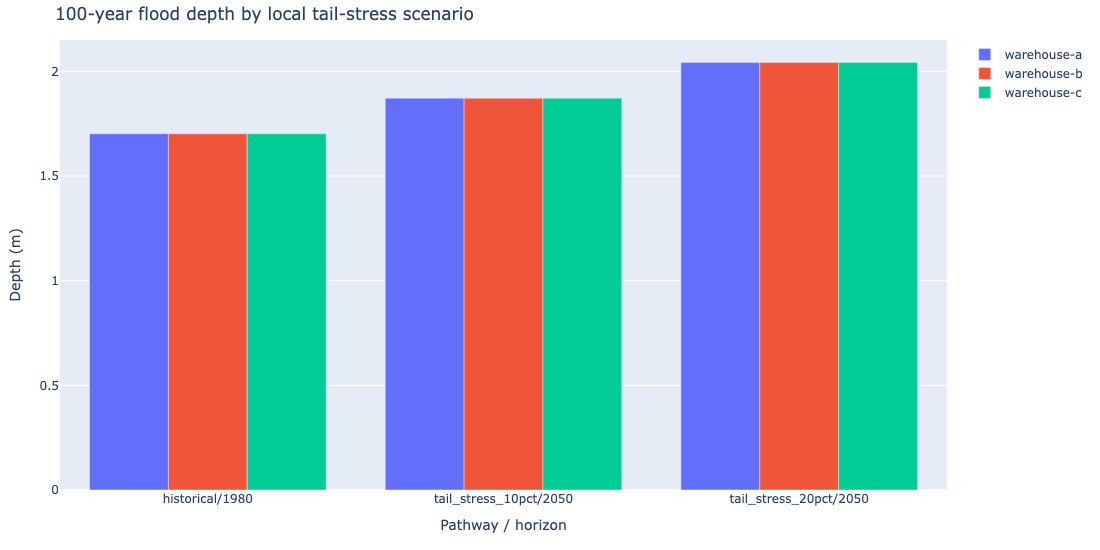

In [5]:
design_col = return_period_value_columns([100])[0]
evaluated = evaluated.assign(
    scenario_label=evaluated["pathway"] + "/" + evaluated["horizon"].astype(str)
)

fig = go.Figure()
for asset_id, frame in evaluated.groupby("asset_id"):
    frame = frame.sort_values(["horizon", "pathway"])
    fig.add_trace(
        go.Bar(
            name=asset_id,
            x=frame["scenario_label"],
            y=frame[design_col],
        )
    )
fig.update_layout(
    barmode="group",
    title="100-year flood depth by local tail-stress scenario",
    xaxis_title="Pathway / horizon",
    yaxis_title="Depth (m)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig.show()


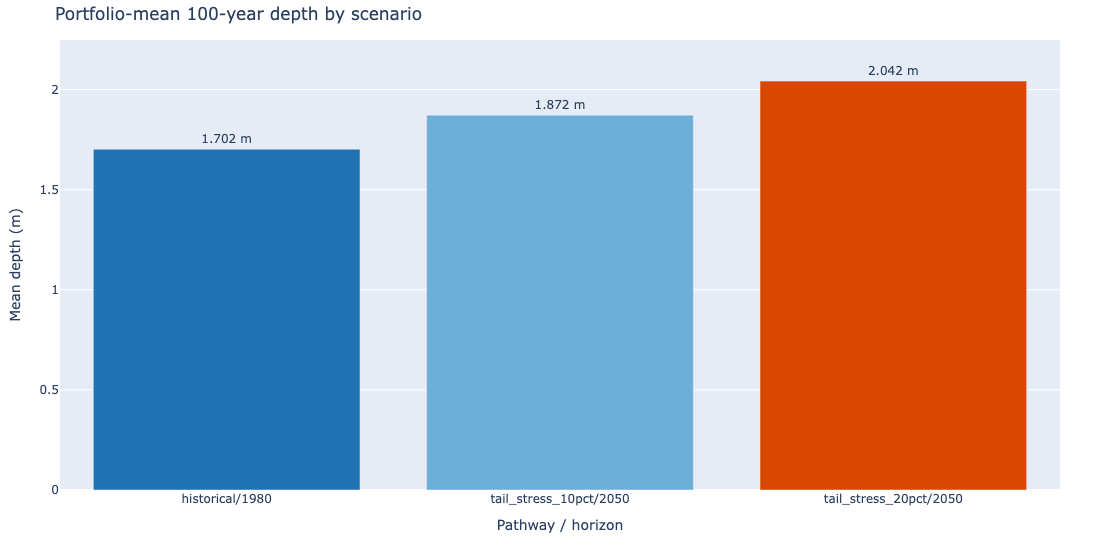

,pathway,horizon,scenario_label,mean_depth_m,total_depth_m
0,historical,1980,historical/1980,1.701981,5.105942
1,tail_stress_10pct,2050,tail_stress_10pct/2050,1.872179,5.616536
2,tail_stress_20pct,2050,tail_stress_20pct/2050,2.042377,6.127130


In [6]:
portfolio = (
    evaluated.groupby(["pathway", "horizon", "scenario_label"], as_index=False)
    .agg(mean_depth_m=(design_col, "mean"), total_depth_m=(design_col, "sum"))
    .sort_values(["horizon", "pathway"])
)
fig_port = go.Figure(
    go.Bar(
        x=portfolio["scenario_label"],
        y=portfolio["mean_depth_m"],
        marker_color=["#2171B5", "#6BAED6", "#D94801"],
        text=[f"{v:.3f} m" for v in portfolio["mean_depth_m"]],
        textposition="outside",
    )
)
fig_port.update_layout(
    title="Portfolio-mean 100-year depth by scenario",
    xaxis_title="Pathway / horizon",
    yaxis_title="Mean depth (m)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_port.show()
portfolio


## Scaling this up

[`pipelines/multi_scenario_pipeline.py`](../pipelines/multi_scenario_pipeline.py)
is the headless twin. Add local stress definitions — or replace them with real
canonical model scenarios later — without changing the portfolio evaluation
call. The distinction should remain explicit: these scale stresses demonstrate
mechanics and are not calibrated projections.
